# 02 — Forward Propagation (TensorFlow / Keras)

We trace one real MNIST image through a deliberately tiny **784 → 4 → 10** network so every intermediate quantity remains inspectable.


## Equations
$$z^{(1)}=xW^{(1)}+b^{(1)},\quad a^{(1)}=\operatorname{ReLU}(z^{(1)})$$
$$z^{(2)}=a^{(1)}W^{(2)}+b^{(2)},\quad \hat y=\operatorname{softmax}(z^{(2)})$$

A matrix multiplication is just many scalar multiply-add operations executed together.


train (5000, 784) test (1000, 784)


2026-09-07 07:30:11.383158: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


true 0
z1 [[ 0.09099474  0.13456947  0.2166348  -0.27910057]]
manual h0 0.09099474549293518 matrix 0.09099473804235458
p [[0.09940578 0.10126976 0.09862617 0.10038928 0.09944031 0.10120085
  0.10139542 0.09757185 0.10002255 0.10067803]] pred 6


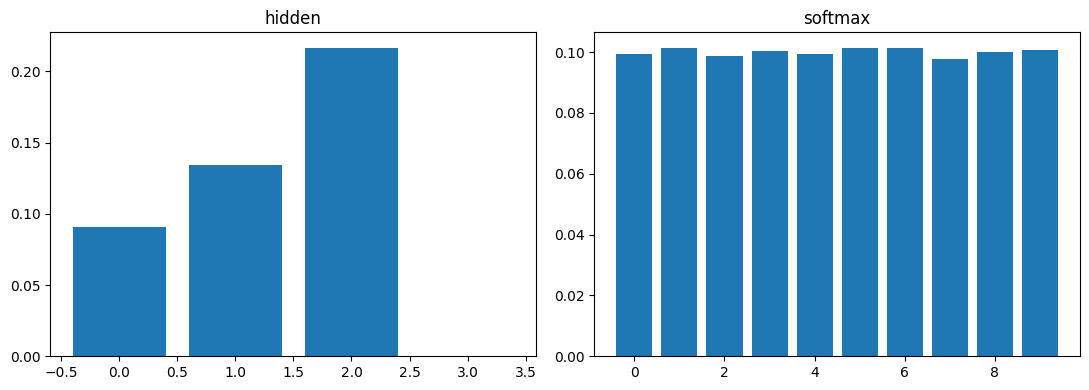

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import tensorflow as tf,matplotlib.pyplot as plt
tf.random.set_seed(42);X=tf.constant(x_train[:1]);W1=tf.random.normal((784,4),stddev=.03,seed=1);b1=tf.zeros(4);W2=tf.random.normal((4,10),stddev=.05,seed=2);b2=tf.zeros(10);z1=X@W1+b1;a1=tf.nn.relu(z1);q=a1@W2+b2;p=tf.nn.softmax(q,1);manual=tf.reduce_sum(X[0]*W1[:,0])+b1[0];print('true',int(y_train[0]));print('z1',z1.numpy());print('manual h0',float(manual.numpy()),'matrix',float(z1[0,0].numpy()));print('p',p.numpy(),'pred',int(tf.argmax(p,1)[0]));fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].bar(range(4),a1.numpy()[0]);axes[1].bar(range(10),p.numpy()[0]);axes[0].set_title('hidden');axes[1].set_title('softmax');plt.tight_layout();plt.show()


**Inference:** no learning happens during forward propagation. With fixed inputs and parameters, the prediction is deterministic. The hidden activation vector is the current learned representation of the image.
